In [ ]:
# The visualizations were aided by generative AI
import glob
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# NOTE: Update model names here
model_names = [
    "Human",
    "gpt-5.4-mini",
    "gemini-3-flash-preview",
    "grok-4.1-fast",
]

discussion_types = {"decideExploration", "decideAttack", "decideDefense", "decideAttackSide"}
# NOTE: Update ship counts here
TOTAL_SHIPS = 5


sessions = []
# NOTE: Edit log folder here
for filepath in sorted(glob.glob("participants/*.jsonl")):
    if filepath.endswith("-labels.jsonl"):
        continue
    session = []
    with open(filepath) as f:
        for line in f:
            session.append(json.loads(line))
    sessions.append(session)

logs = sessions

In [2]:
statistics = {i: {"total_ships_sent": 0, "total_gold_acquired": 0, "total_gold_at_game_end": 0,
             "total_times_defender": 0, "total_times_attacker": 0, "total_win_count": 0,
             "total_discussion_chars": 0, "total_decisions": 0}
         for i in range(len(model_names))}

for session in logs:
    for log in session:
        t = log["type"]

        if t == "decideExploration":
            p_id = log["playerId"]
            statistics[p_id]["total_ships_sent"] += log["explorationShipCount"]

        elif t == "explorationResolved":
            for p in log["players"]:
                p_id = p["playerId"]
                if p["goldChange"] > 0:
                    statistics[p_id]["total_gold_acquired"] += p["goldChange"]

        elif t == "attackResolved":
            for p in log["players"]:
                p_id = p["playerId"]
                if p["goldChange"] > 0:
                    statistics[p_id]["total_gold_acquired"] += p["goldChange"]
            statistics[log["attackerId"]]["total_times_attacker"] += 1
            statistics[log["defenderId"]]["total_times_defender"] += 1

        elif t == "gameEnded":
            for p in log["players"]:
                statistics[p["id"]]["total_gold_at_game_end"] += p["gold"]
            statistics[log["winnerId"]]["total_win_count"] += 1

        if t in discussion_types:
            discussion = log.get("discussion", "")
            if discussion.strip():
                p_id = log["playerId"]
                statistics[p_id]["total_discussion_chars"] += len(discussion)
                statistics[p_id]["total_decisions"] += 1

df = pd.DataFrame.from_dict(
    {model_names[p_id]: s for p_id, s in statistics.items()},
    orient="index"
).reset_index().rename(columns={"index": "player"})
df["chars_per_decision"] = df["total_discussion_chars"] / df["total_decisions"]
df = df.reset_index(drop=True)
df

,player,total_ships_sent,total_gold_acquired,total_gold_at_game_end,total_times_defender,total_times_attacker,total_win_count,total_discussion_chars,total_decisions,chars_per_decision
0,Human,331,510,394,42,39,3,12542,171,73.345029
1,gpt-5.4-mini,311,466,382,27,31,3,24250,265,91.509434
2,gemini-3-flash-preview,403,549,469,35,35,11,61057,262,233.041985
3,grok-4.1-fast,380,548,516,29,28,11,36606,261,140.252874


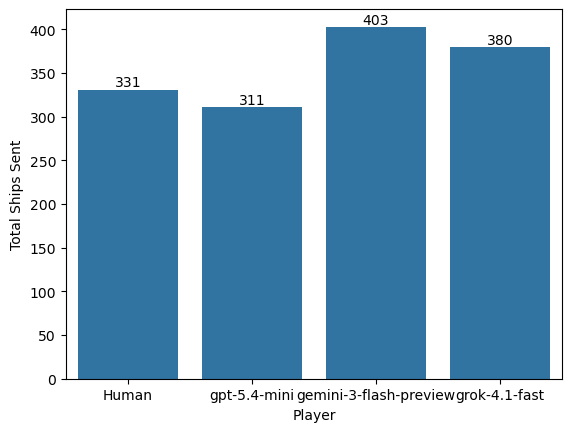

In [3]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_ships_sent", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Ships Sent")
plt.show()

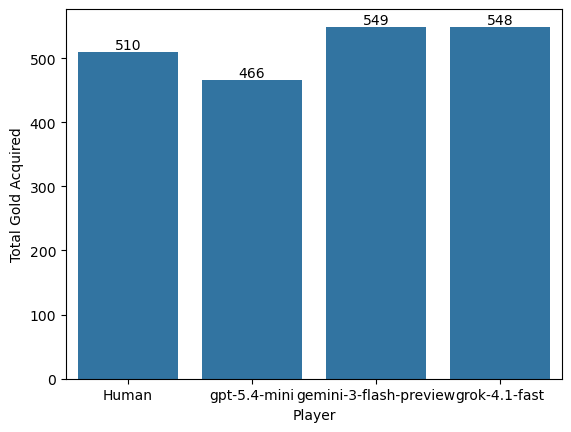

In [4]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_gold_acquired", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Gold Acquired")
plt.show()

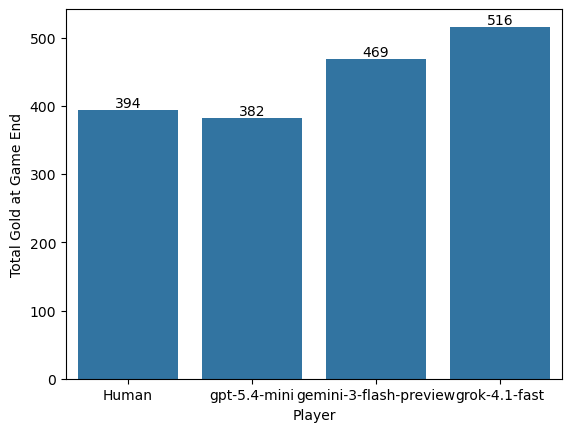

In [5]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_gold_at_game_end", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Gold at Game End")
plt.show()

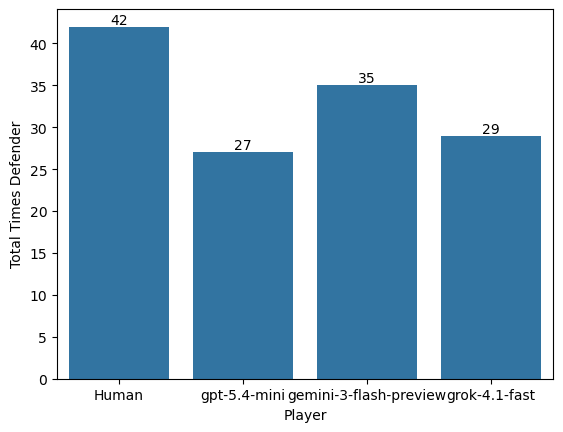

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_times_defender", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Times Defender")
plt.show()

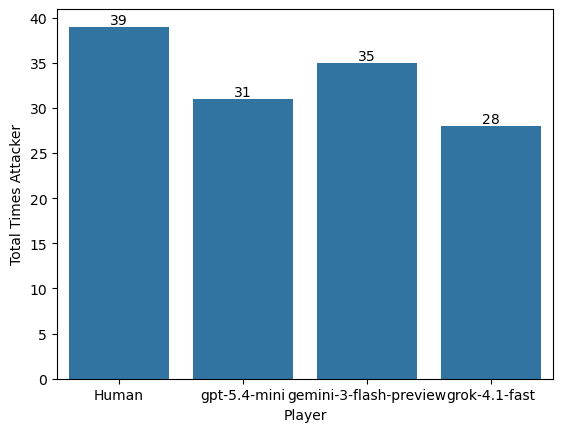

In [7]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_times_attacker", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Times Attacker")
plt.show()

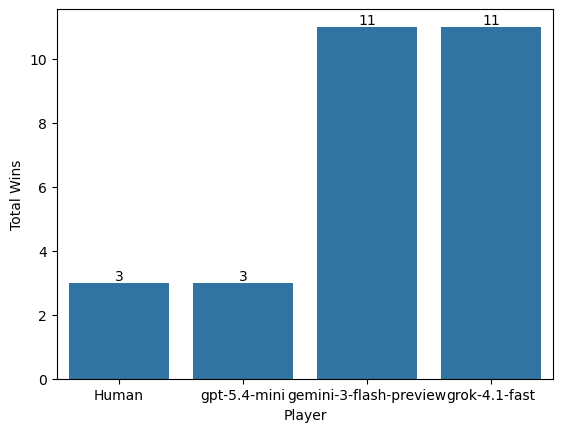

In [8]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="player", y="total_win_count", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.0f")

ax.set_xlabel("Player")
ax.set_ylabel("Total Wins")
plt.show()

In [9]:
decision_rows = []
for session in logs:
    for log in session:
        if log["type"] in discussion_types:
            discussion = log.get("discussion", "")
            if discussion.strip():
                decision_rows.append({
                    "player": model_names[log["playerId"]],
                    "chars": len(discussion),
                })

decision_df = pd.DataFrame(decision_rows)
decision_df.groupby("player")["chars"].describe().reindex(model_names)

,count,mean,std,min,25%,50%,75%,max
player,,,,,,,,
Human,171.0,73.345029,51.936310,5.0,35.0,60.0,91.00,288.0
gpt-5.4-mini,265.0,91.509434,20.487452,41.0,78.0,90.0,105.00,148.0
gemini-3-flash-preview,262.0,233.041985,69.261914,92.0,185.0,226.0,273.75,456.0
grok-4.1-fast,261.0,140.252874,36.267771,65.0,114.0,138.0,164.00,258.0


In [10]:
exploration_rows = []
for session in logs:
    for log in session:
        if log["type"] == "decideExploration":
            name = model_names[log["playerId"]]
            exploration_rows.append({
                "player": name,
                "exploration_ships": log["explorationShipCount"],
                "home_ships": TOTAL_SHIPS - log["explorationShipCount"],
            })

exploration_df = pd.DataFrame(exploration_rows)

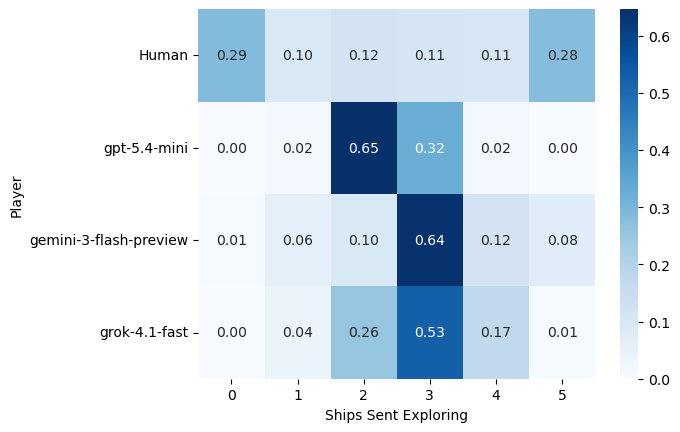

In [11]:
freq = exploration_df.groupby(["player", "exploration_ships"]).size().unstack(fill_value=0)
freq = freq.reindex(model_names)
freq = freq.div(freq.sum(axis=1), axis=0)

fig, ax = plt.subplots()
sns.heatmap(freq, annot=True, fmt=".2f", cmap="Blues", ax=ax)

ax.set_xlabel("Ships Sent Exploring")
ax.set_ylabel("Player")
plt.show()